# Basic classification model on the cifar-10 dataset

In [1]:
import sys
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(parent_dir)

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader   
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid
from utils.cnn_architecture import SimpleCNN

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Load the data

In [4]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Augmentation: random flip
    transforms.RandomCrop(32, padding=4),  # Augmentation: random crop
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

In [5]:
# Load CIFAR-10 dataset
train_dataset = torchvision.datasets.CIFAR10(root='../data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='../data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [6]:
# Split the training dataset into training and validation sets (Here, 80% train, 20% val)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

In [7]:
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=2)

### Training function

In [8]:
def train_model(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Use tqdm for the progress bar
    progress_bar = tqdm(train_loader, desc="Training", leave=False)
    
    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        progress_bar.set_postfix(loss=running_loss / (total / labels.size(0)), accuracy=100. * correct / total)
    
    epoch_loss = running_loss / len(train_loader)
    accuracy = 100. * correct / total
    return epoch_loss, accuracy

### Evaluation function 

In [9]:
def evaluate_model(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(val_loader, desc="Validating", leave=False)
    
    with torch.no_grad():
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            progress_bar.set_postfix(loss=running_loss / (total / labels.size(0)), accuracy=100. * correct / total)
    
    epoch_loss = running_loss / len(val_loader)
    accuracy = 100. * correct / total
    return epoch_loss, accuracy

### Model Training

In [10]:
model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

num_epochs = 30

In [11]:
for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    
    train_loss, train_accuracy = train_model(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = evaluate_model(model, val_loader, criterion, device)
    
    # Append metrics to lists
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    
    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")
    print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%\n")

Epoch 1/30


Train Loss: 1.6079, Train Accuracy: 39.87%
Validation Loss: 1.4086, Validation Accuracy: 47.98%

Epoch 2/30


Train Loss: 1.2487, Train Accuracy: 54.66%
Validation Loss: 1.1650, Validation Accuracy: 57.87%

Epoch 3/30


Train Loss: 1.0977, Train Accuracy: 60.77%
Validation Loss: 1.1086, Validation Accuracy: 60.05%

Epoch 4/30


Train Loss: 1.0057, Train Accuracy: 64.50%
Validation Loss: 1.0955, Validation Accuracy: 61.19%

Epoch 5/30


...

Train Loss: 0.5645, Train Accuracy: 80.39%
Validation Loss: 0.6389, Validation Accuracy: 77.57%

Epoch 27/30


Train Loss: 0.5594, Train Accuracy: 80.49%
Validation Loss: 0.6638, Validation Accuracy: 77.16%

Epoch 28/30


Train Loss: 0.5509, Train Accuracy: 80.94%
Validation Loss: 0.6224, Validation Accuracy: 77.81%

Epoch 29/30


Train Loss: 0.5373, Train Accuracy: 81.35%
Validation Loss: 0.5969, Validation Accuracy: 78.91%

Epoch 30/30


Train Loss: 0.5348, Train Accuracy: 81.51%
Validation Loss: 0.6180, Validation Accuracy: 78.78%



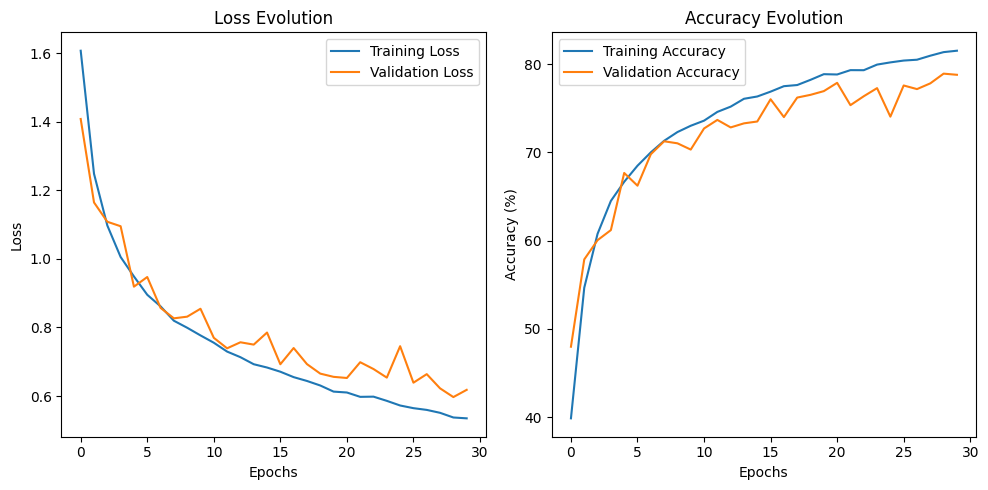

In [12]:
plt.figure(figsize=(10, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss Evolution')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Accuracy Evolution')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

### Model Evaluation

In [13]:
test_loss, test_accuracy = evaluate_model(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.6028, Test Accuracy: 79.18%


In [16]:
torch.save(model, '../models/cifar10_basic_model.pth')